In [1]:
# Clearing the environment

try:
    del full_dataset, train_indices, val_indices, train_subset, val_subset, train_loader, val_loader, labels, class_names, model, criterion, optimizer
except NameError:
    print("Some are non-existent!")

!rm -rf /kaggle/working/*
%reset -f


import gc

def reset_memory():
    # Delete all variables.
    for var in gc.get_objects():
        try:
            del var
        except:
            pass

    # Run the garbage collector.
    gc.collect()

    print("Memory has been reset")

# Call the function to reset memory

reset_memory()

Some are non-existent!
Memory has been reset


In [1]:
# Install required packages
# !pip install transformers datasets evaluate accelerate

import json
import numpy as np
from PIL import Image
from skimage.draw import polygon
import torch
from torch.utils.data import Dataset, DataLoader
import os
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==================== Data Loading ====================

def load_annotations_from_files(json_path, text_path, height, width):
    """
    Load masks from JSON and labels from text file.
    Returns dict with boxes, labels, and masks.
    """
    with open(json_path) as f:
        json_data = json.load(f)
    
    with open(text_path) as g:
        labels = []
        for line in g:
            # First integer in each line is the label (0-3)
            labels.append(int(line.strip().split()[0]))
    
    masks = []
    boxes = []
    
    for shape in json_data["shapes"]:
        pts = np.array(shape["points"], dtype=np.int32)
        rr, cc = polygon(pts[:, 1], pts[:, 0], (height, width))
        
        mask = np.zeros((height, width), dtype=np.uint8)
        mask[rr, cc] = 1
        masks.append(mask)
        
        # Bounding box [x_min, y_min, x_max, y_max]
        x_min, y_min = pts[:, 0].min(), pts[:, 1].min()
        x_max, y_max = pts[:, 0].max(), pts[:, 1].max()
        boxes.append([x_min, y_min, x_max, y_max])
    
    return {
        "boxes": np.array(boxes, dtype=np.float32),
        "labels": np.array(labels, dtype=np.int64),
        "masks": np.stack(masks, axis=0) if masks else np.zeros((0, height, width), dtype=np.uint8)
    }

# ==================== Dataset Class ====================

class BacteriaDatasetMask2Former(Dataset):
    def __init__(self, img_dir, json_dir, text_dir, processor, train=True):
        self.img_dir = img_dir
        self.json_dir = json_dir
        self.text_dir = text_dir
        self.processor = processor
        self.train = train
        
        self.imgs = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
    
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        # Derive json and text filenames
        base_name = img_name.replace('.jpg', '')
        json_path = os.path.join(self.json_dir, base_name + '.json')
        text_path = os.path.join(self.text_dir, base_name + '.txt')
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        w, h = image.size
        
        # Load annotations
        annotations = load_annotations_from_files(json_path, text_path, h, w)
        
        num_instances = len(annotations["masks"])
        
        if num_instances == 0:
            # Handle empty annotations - create dummy instance
            # This is needed for processor to work correctly
            encoding = self.processor(
                images=image,
                return_tensors="pt"
            )
            # Add empty targets
            encoding["class_labels"] = torch.tensor([], dtype=torch.long).reshape(0)
            encoding["mask_labels"] = torch.zeros((0, h, w), dtype=torch.float32)
            
            # Remove batch dimension
            for k, v in encoding.items():
                if isinstance(v, torch.Tensor) and v.dim() > 1:
                    encoding[k] = v.squeeze(0)
            
            return encoding
        
        # Convert masks to list of binary masks (each mask is 2D)
        masks_list = [annotations["masks"][i] for i in range(num_instances)]
        class_labels = annotations["labels"].tolist()
        
        # Encode using the processor's preferred format
        # Pass masks as a list and class_labels separately
        encoding = self.processor(
            images=image,
            # Don't pass segmentation_maps, instead we'll manually create targets
            return_tensors="pt"
        )
        
        # Manually create the target masks and labels
        # Resize masks to match the processor's output size
        processor_size = encoding["pixel_values"].shape[-2:]  # (H, W)
        
        # Resize each mask to match processor output
        resized_masks = []
        for mask in masks_list:
            # Convert to PIL, resize, convert back
            mask_pil = Image.fromarray((mask * 255).astype(np.uint8))
            mask_resized = mask_pil.resize((processor_size[1], processor_size[0]), Image.NEAREST)
            mask_resized = np.array(mask_resized) > 0
            resized_masks.append(mask_resized)
        
        # Stack masks (N, H, W)
        mask_labels = np.stack(resized_masks, axis=0).astype(np.float32)
        
        # Add to encoding
        encoding["mask_labels"] = torch.from_numpy(mask_labels)
        encoding["class_labels"] = torch.tensor(class_labels, dtype=torch.long)
        
        # Remove batch dimension from pixel_values and pixel_mask
        for k in ["pixel_values", "pixel_mask"]:
            if k in encoding and encoding[k].dim() > 3:
                encoding[k] = encoding[k].squeeze(0)
        
        return encoding

# ==================== Model Setup ====================

def setup_model_and_processor(num_classes=4, image_size=256):
    """
    Initialize Mask2Former model and processor.
    num_classes: number of object classes (excluding background)
    image_size: size to resize images (default 256 to match dataset)
    """
    model_name = "facebook/mask2former-swin-tiny-coco-instance"
    
    processor = Mask2FormerImageProcessor.from_pretrained(
        model_name,
        do_reduce_labels=False,
        ignore_index=255,
        size={"height": image_size, "width": image_size}  # Keep original 256x256 size
    )
    
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    
    return model, processor

# ==================== Instance Segmentation Metrics ====================

def compute_instance_metrics_classwise(preds, targets, num_classes, iou_thresh=0.5, smooth=1e-6):
    """
    Compute instance segmentation metrics per class.
    preds: list of dicts with "masks" and "labels" from model predictions
    targets: list of dicts with "masks" and "labels" from ground truth
    num_classes: total number of object classes
    """
    class_stats = {cls: {"tp": 0, "fp": 0, "fn": 0, "ious": []} for cls in range(num_classes)}

    for pred, tgt in zip(preds, targets):
        # Handle predictions - masks are already binary
        if len(pred["masks"]) > 0:
            pred_masks = pred["masks"]  # Already numpy arrays
            pred_labels = pred["labels"]
        else:
            pred_masks = []
            pred_labels = []
        
        # Handle targets
        if len(tgt["masks"]) > 0:
            tgt_masks = tgt["masks"]
            tgt_labels = tgt["labels"]
        else:
            tgt_masks = []
            tgt_labels = []

        for cls in range(num_classes):
            pmasks = [m for m, l in zip(pred_masks, pred_labels) if l == cls]
            tmasks = [m for m, l in zip(tgt_masks, tgt_labels) if l == cls]
            matched_gt = set()

            for pm in pmasks:
                best_iou = 0.0
                best_idx = -1
                for i, tm in enumerate(tmasks):
                    inter = np.logical_and(pm, tm).sum()
                    union = np.logical_or(pm, tm).sum()
                    iou = (inter + smooth) / (union + smooth)
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = i
                if best_iou >= iou_thresh:
                    class_stats[cls]["tp"] += 1
                    class_stats[cls]["ious"].append(best_iou)
                    matched_gt.add(best_idx)
                else:
                    class_stats[cls]["fp"] += 1

            # count false negatives
            class_stats[cls]["fn"] += len(tmasks) - len(matched_gt)

    # --- Compute metrics per class ---
    results = {}
    for cls in range(num_classes):
        tp = class_stats[cls]["tp"]
        fp = class_stats[cls]["fp"]
        fn = class_stats[cls]["fn"]
        ious = class_stats[cls]["ious"]

        precision = tp / (tp + fp + smooth)
        recall = tp / (tp + fn + smooth)
        mean_iou = np.mean(ious) if ious else 0.0
        dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        acc = tp / (tp + fp + fn + smooth)

        results[f"precision_class_{cls}"] = precision
        results[f"recall_class_{cls}"] = recall
        results[f"iou_class_{cls}"] = mean_iou
        results[f"dice_class_{cls}"] = dice
        results[f"accuracy_class_{cls}"] = acc

    # --- Mean (macro) metrics ---
    results["mean_precision"] = np.mean([results[f"precision_class_{c}"] for c in range(num_classes)])
    results["mean_recall"]    = np.mean([results[f"recall_class_{c}"] for c in range(num_classes)])
    results["mean_iou"]       = np.mean([results[f"iou_class_{c}"] for c in range(num_classes)])
    results["mean_dice"]      = np.mean([results[f"dice_class_{c}"] for c in range(num_classes)])
    results["mean_accuracy"]  = np.mean([results[f"accuracy_class_{c}"] for c in range(num_classes)])

    return results

# ==================== Training Loop ====================

def collate_fn(batch):
    """Custom collate function for Mask2Former."""
    # Stack pixel values and masks
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    pixel_mask = torch.stack([item["pixel_mask"] for item in batch])
    
    # Keep class_labels and mask_labels as lists (variable number per image)
    class_labels = [item["class_labels"] for item in batch]
    mask_labels = [item["mask_labels"] for item in batch]
    
    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "class_labels": class_labels,
        "mask_labels": mask_labels
    }

def train_mask2former(
    img_dir,
    json_dir,
    text_dir,
    num_classes=4,
    epochs=50,
    batch_size=16,
    learning_rate=1e-4,
    device="cuda",
    image_size=256
):
    """
    Main training function for Mask2Former on bacteria dataset.
    """
    print("Setting up model and processor...")
    # Setup model and processor
    model, processor = setup_model_and_processor(num_classes, image_size)
    model.to(device)
    
    print("Creating datasets...")
    def get_fold_indices_sequential(dataset_size, fold_idx, n_folds=5):
        
        all_indices = np.arange(dataset_size)
        
        # Calculate the size of each fold
        fold_size = dataset_size // n_folds
        
        # Calculate start and end indices for validation set
        val_start = (fold_idx - 1) * fold_size
        
        # For the last fold, include any remaining samples
        if fold_idx == n_folds:
            val_end = dataset_size
        else:
            val_end = fold_idx * fold_size
        
        # Get validation indices
        val_idx = all_indices[val_start:val_end]
        
        # Get train indices: all indices except validation indices
        train_idx = np.concatenate([all_indices[:val_start], all_indices[val_end:]])
        
        return train_idx, val_idx

    # Example usage for a specific fold
    fold_idx = 3  # Change this to 1, 2, 3, 4, or 5
    
    # Create full dataset
    full_dataset = BacteriaDatasetMask2Former(img_dir, json_dir, text_dir, processor, train=True)
    
    # Get fold-specific splits
    train_idx, val_idx = get_fold_indices_sequential(len(full_dataset), fold_idx)
    
    print(f"\nFold {fold_idx}:")
    print(f"Train: {len(train_idx)} samples")
    print(f"Val: {len(val_idx)} samples")
    print(f"Val indices range: [{val_idx[0]} - {val_idx[-1]}]")
    
    # Create train subset
    train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
    
    # Create validation dataset with train=False for no augmentation
    val_dataset_full = BacteriaDatasetMask2Former(img_dir, json_dir, text_dir, processor, train=False)
    val_dataset = torch.utils.data.Subset(val_dataset_full, val_idx)
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True
    )
    
    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.0001)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # Training history
    train_losses = []
    val_losses = []
    train_history = []
    val_history = []
    best_dice = 0.0
    best_model_path = "best_mask2former_bacteria.pth"
    
    print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples")
    print(f"Number of model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")
    
    for epoch in range(epochs):
        # ========== Training ==========
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch_idx, batch in enumerate(pbar):
            try:
                pixel_values = batch["pixel_values"].to(device)
                pixel_mask = batch["pixel_mask"].to(device)
                
                # Move targets to device
                class_labels = [labels.to(device) for labels in batch["class_labels"]]
                mask_labels = [masks.to(device) for masks in batch["mask_labels"]]
                
                # Forward pass
                outputs = model(
                    pixel_values=pixel_values,
                    pixel_mask=pixel_mask,
                    mask_labels=mask_labels,
                    class_labels=class_labels
                )
                
                loss = outputs.loss
                
                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                
                train_loss += loss.item()
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})
                
            except Exception as e:
                print(f"\nError in batch {batch_idx}: {e}")
                continue
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_history.append({"loss": avg_train_loss})
        
        # ========== Validation with Metrics ==========
        model.eval()
        val_loss = 0.0
        val_metrics_list = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                try:
                    pixel_values = batch["pixel_values"].to(device)
                    pixel_mask = batch["pixel_mask"].to(device)
                    
                    class_labels = [labels.to(device) for labels in batch["class_labels"]]
                    mask_labels = [masks.to(device) for masks in batch["mask_labels"]]
                    
                    # Get loss
                    outputs = model(
                        pixel_values=pixel_values,
                        pixel_mask=pixel_mask,
                        mask_labels=mask_labels,
                        class_labels=class_labels
                    )
                    
                    val_loss += outputs.loss.item()
                    
                    # Get predictions for metrics
                    # Run inference mode
                    pred_outputs = model(
                        pixel_values=pixel_values,
                        pixel_mask=pixel_mask
                    )
                    
                    # Post-process predictions
                    target_sizes = [(image_size, image_size)] * len(pixel_values)
                    results = processor.post_process_instance_segmentation(
                        pred_outputs,
                        threshold=0.5,
                        target_sizes=target_sizes
                    )
                    
                    # Convert predictions and targets to the format expected by metrics
                    batch_preds = []
                    batch_targets = []
                    
                    for i in range(len(results)):
                        # Predictions
                        pred_masks_raw = results[i]["segmentation"].cpu().numpy()
                        pred_segments = results[i]["segments_info"]
                        
                        pred_masks = []
                        pred_labels_list = []
                        
                        for seg in pred_segments:
                            seg_id = seg["id"]
                            label_id = seg["label_id"]
                            mask = (pred_masks_raw == seg_id).astype(np.uint8)
                            pred_masks.append(mask)
                            pred_labels_list.append(label_id)
                        
                        batch_preds.append({
                            "masks": pred_masks,
                            "labels": pred_labels_list
                        })
                        
                        # Targets
                        tgt_masks = mask_labels[i].cpu().numpy()
                        tgt_labels = class_labels[i].cpu().numpy()
                        
                        batch_targets.append({
                            "masks": [tgt_masks[j] for j in range(len(tgt_masks))],
                            "labels": tgt_labels.tolist()
                        })
                    
                    # Compute metrics for this batch
                    metrics = compute_instance_metrics_classwise(
                        batch_preds, 
                        batch_targets, 
                        num_classes=num_classes,
                        iou_thresh=0.5
                    )
                    val_metrics_list.append(metrics)
                    
                except Exception as e:
                    print(f"\nValidation error: {e}")
                    import traceback
                    traceback.print_exc()
                    continue
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Average metrics across batches
        if val_metrics_list:
            val_metrics = {k: np.mean([m[k] for m in val_metrics_list]) for k in val_metrics_list[0].keys()}
            val_metrics["loss"] = avg_val_loss
            val_metrics["dice_loss"] = 1 - val_metrics["mean_dice"]
            val_metrics["iou_loss"] = 1 - val_metrics["mean_iou"]
        else:
            val_metrics = {
                "loss": avg_val_loss,
                "mean_dice": 0.0,
                "dice_loss": 1.0,
                "mean_iou": 0.0,
                "iou_loss": 1.0,
                "mean_precision": 0.0,
                "mean_recall": 0.0,
                "mean_accuracy": 0.0
            }
        
        val_history.append(val_metrics)
        
        # Step scheduler
        scheduler.step()
        
        # === Logging ===
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f} || "
              f"Dice: {val_metrics['mean_dice']:.4f}, Dice Loss: {val_metrics['dice_loss']:.4f} | "
              f"IoU: {val_metrics['mean_iou']:.4f}, IoU Loss: {val_metrics['iou_loss']:.4f} | "
              f"Prec: {val_metrics['mean_precision']:.4f}, Recall: {val_metrics['mean_recall']:.4f}, Accuracy: {val_metrics['mean_accuracy']:.4f}")
        
        # === Save best model based on Dice score ===
        if val_metrics["mean_dice"] > best_dice:
            best_dice = val_metrics["mean_dice"]
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': avg_val_loss,
                'dice': best_dice,
            }, best_model_path)
            print(f"  -> Saved new best model (Dice={best_dice:.4f})")
    
    return model, processor, train_losses, val_losses, train_history, val_history

In [2]:
# ==================== Usage ====================

if __name__ == "__main__":
    IMG_DIR = "/kaggle/input/640DataSet/images/"
    JSON_DIR = "/kaggle/input/640DataSet/json/"
    LBL_DIR = "/kaggle/input/640DataSet/labels/"
    
    # Label mapping (for reference)
    label_map = {
        0: {"name": "G-cocci", "color": "red"},
        1: {"name": "G+cocci", "color": "green"},
        2: {"name": "G-bacilli", "color": "blue"},
        3: {"name": "G+bacilli", "color": "cyan"}
    }
    
    # Train the model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model, processor, train_losses, val_losses, train_history, val_history = train_mask2former(
        img_dir=IMG_DIR,
        json_dir=JSON_DIR,
        text_dir=LBL_DIR,
        num_classes=4,
        epochs=25,
        batch_size=16,
        learning_rate=1e-4,
        device=device,
        image_size=256
    )

Setting up model and processor...


preprocessor_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/190M [00:00<?, ?B/s]

...

Epoch 23/25 | Train Loss: 4.8363, Val Loss: 12.1279 || Dice: 0.6928, Dice Loss: 0.3072 | IoU: 0.5462, IoU Loss: 0.4538 | Prec: 0.4958, Recall: 0.5323, Accuracy: 0.4138
  -> Saved new best model (Dice=0.6928)


Epoch 24/25 [Val]: 100%|██████████| 76/76 [01:03<00:00,  1.19it/s]


Epoch 24/25 | Train Loss: 4.8061, Val Loss: 12.1338 || Dice: 0.6936, Dice Loss: 0.3064 | IoU: 0.5470, IoU Loss: 0.4530 | Prec: 0.4918, Recall: 0.5319, Accuracy: 0.4109
  -> Saved new best model (Dice=0.6936)


Epoch 25/25 [Val]: 100%|██████████| 76/76 [01:03<00:00,  1.19it/s]


Epoch 25/25 | Train Loss: 4.7871, Val Loss: 12.1929 || Dice: 0.6952, Dice Loss: 0.3048 | IoU: 0.5473, IoU Loss: 0.4527 | Prec: 0.4965, Recall: 0.5312, Accuracy: 0.4126
  -> Saved new best model (Dice=0.6952)


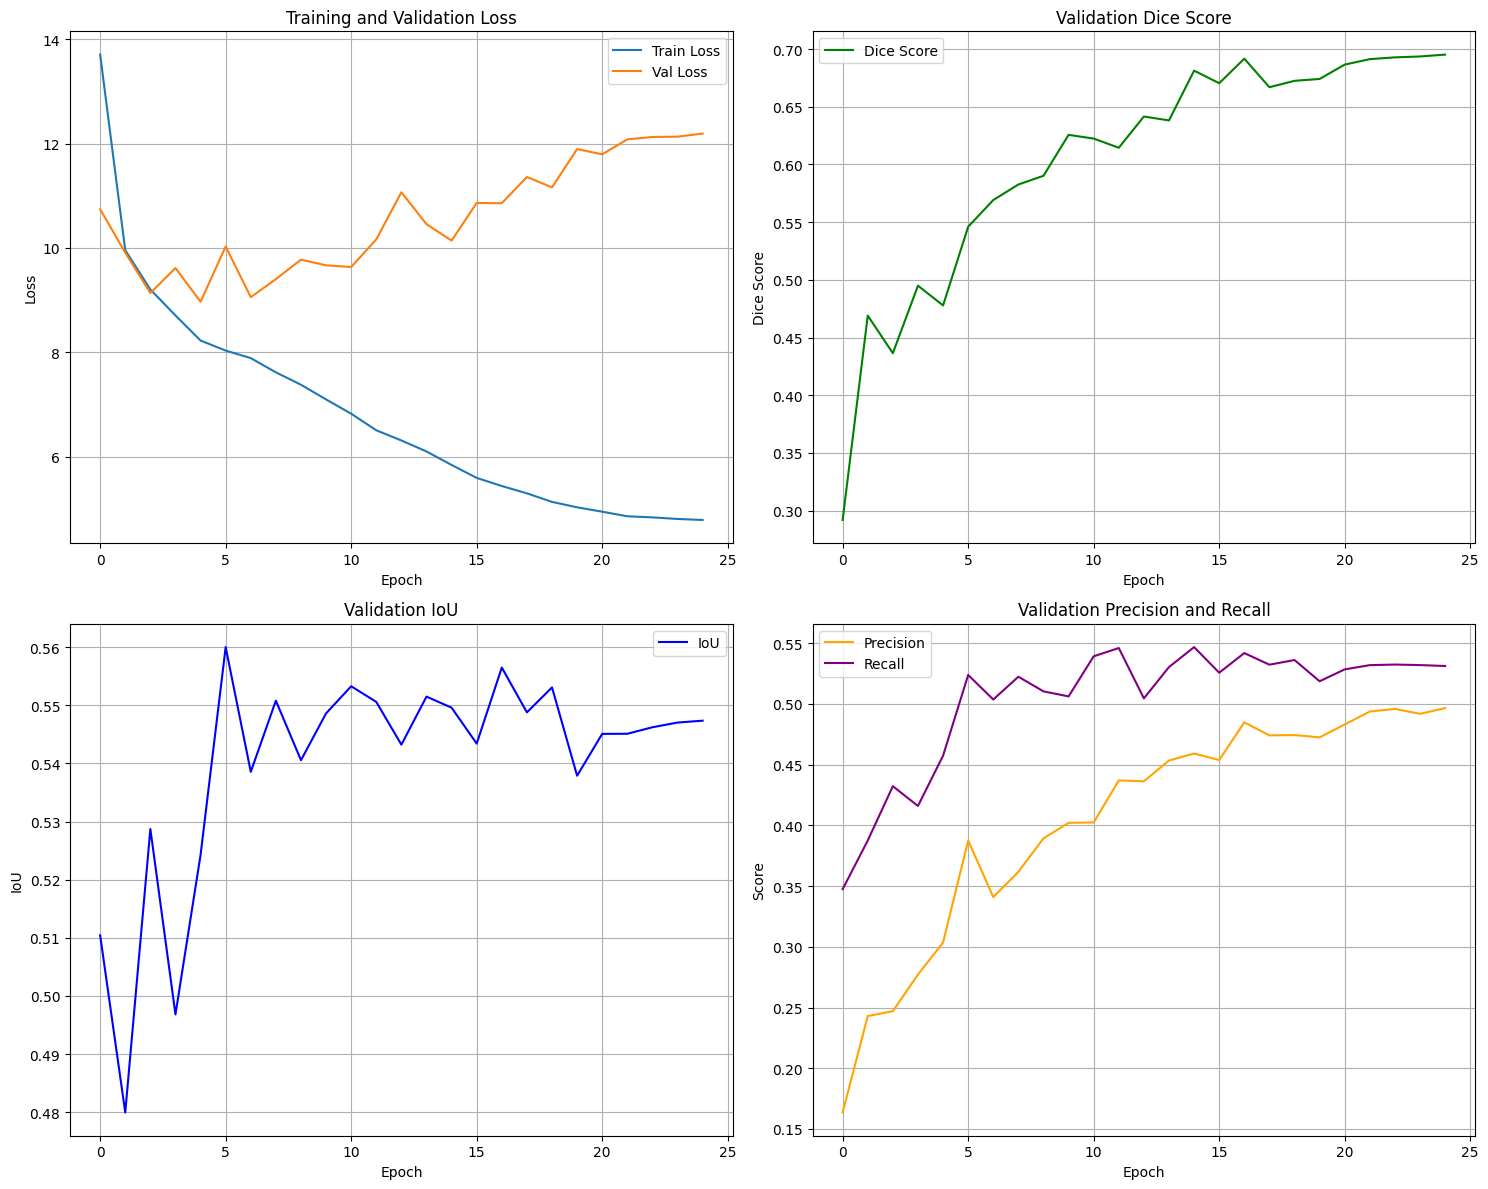


Training completed!
Best Dice Score: 0.6952
Best IoU: 0.5600


In [3]:
# Plot training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Loss curves
axes[0, 0].plot(train_losses, label='Train Loss')
axes[0, 0].plot(val_losses, label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].grid(True)

# Dice score
dice_scores = [h["mean_dice"] for h in val_history]
axes[0, 1].plot(dice_scores, label='Dice Score', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Dice Score')
axes[0, 1].legend()
axes[0, 1].set_title('Validation Dice Score')
axes[0, 1].grid(True)

# IoU
iou_scores = [h["mean_iou"] for h in val_history]
axes[1, 0].plot(iou_scores, label='IoU', color='blue')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('IoU')
axes[1, 0].legend()
axes[1, 0].set_title('Validation IoU')
axes[1, 0].grid(True)

# Precision and Recall
precision = [h["mean_precision"] for h in val_history]
recall = [h["mean_recall"] for h in val_history]
axes[1, 1].plot(precision, label='Precision', color='orange')
axes[1, 1].plot(recall, label='Recall', color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].set_title('Validation Precision and Recall')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()

print("\n" + "="*50)
print("Training completed!")
print(f"Best Dice Score: {max(dice_scores):.4f}")
print(f"Best IoU: {max(iou_scores):.4f}")
print("="*50)

In [2]:
IMG_DIR = "/kaggle/input/640DataSet/images/"
JSON_DIR = "/kaggle/input/640DataSet/json/"
LBL_DIR = "/kaggle/input/640DataSet/labels/"

def get_fold_indices_sequential(dataset_size, fold_idx, n_folds=5):
        
    all_indices = np.arange(dataset_size)
    
    # Calculate the size of each fold
    fold_size = dataset_size // n_folds
    
    # Calculate start and end indices for validation set
    val_start = (fold_idx - 1) * fold_size
    
    # For the last fold, include any remaining samples
    if fold_idx == n_folds:
        val_end = dataset_size
    else:
        val_end = fold_idx * fold_size
    
    # Get validation indices
    val_idx = all_indices[val_start:val_end]
    
    # Get train indices: all indices except validation indices
    train_idx = np.concatenate([all_indices[:val_start], all_indices[val_end:]])
    
    return train_idx, val_idx

# Example usage for a specific fold
fold_idx = 3  # Change this to 1, 2, 3, 4, or 5

# Create full dataset
full_dataset = BacteriaDatasetMask2Former(IMG_DIR, JSON_DIR, LBL_DIR, processor, train=True)

# Get fold-specific splits
train_idx, val_idx = get_fold_indices_sequential(len(full_dataset), fold_idx)

# Create train subset
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)

# Create validation dataset with train=False for no augmentation
val_dataset_full = BacteriaDatasetMask2Former(IMG_DIR, JSON_DIR, LBL_DIR, processor, train=False)
val_dataset = torch.utils.data.Subset(val_dataset_full, val_idx)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True
)

preprocessor_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/190M [00:00<?, ?B/s]

Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-tiny-coco-instance and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([81]) in the checkpoint and torch.Size([5]) in the model instantiated
- class_predictor.weight: found shape torch.Size([81, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([81]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded model from epoch 24
Best Dice score: 0.6952
CUDA is available. Using GPU: Tesla P100-PCIE-16GB
Running inference on validation set...


Inference: 100%|██████████| 76/76 [00:35<00:00,  2.16it/s]



Collected 1201 predictions and 1201 targets

Computing Detection Metrics...
Computing Classification Metrics...
Computing Segmentation Metrics...

COMPREHENSIVE EVALUATION RESULTS
OBJECT DETECTION METRICS

G-cocci:
  Precision: 0.6775
  Recall:    0.8463
  F1 Score:  0.7525
  AP:        0.6701

G+cocci:
  Precision: 0.6369
  Recall:    0.5879
  F1 Score:  0.6114
  AP:        0.4577

G-bacilli:
  Precision: 0.8055
  Recall:    0.8116
  F1 Score:  0.8085
  AP:        0.7637

G+bacilli:
  Precision: 0.8000
  Recall:    0.6531
  F1 Score:  0.7191
  AP:        0.5845

Overall Detection:
  Mean Precision: 0.7300
  Mean Recall:    0.7247
  Mean F1:        0.7229
  mAP:            0.6190

CLASSIFICATION METRICS

G-cocci:
  Accuracy:  0.8545
  Precision: 0.6775
  Recall:    0.8463
  F1 Score:  0.7525

G+cocci:
  Accuracy:  0.9394
  Precision: 0.6369
  Recall:    0.5879
  F1 Score:  0.6114

G-bacilli:
  Accuracy:  0.8150
  Precision: 0.8055
  Recall:    0.8116
  F1 Score:  0.8085

G+bacilli:
  

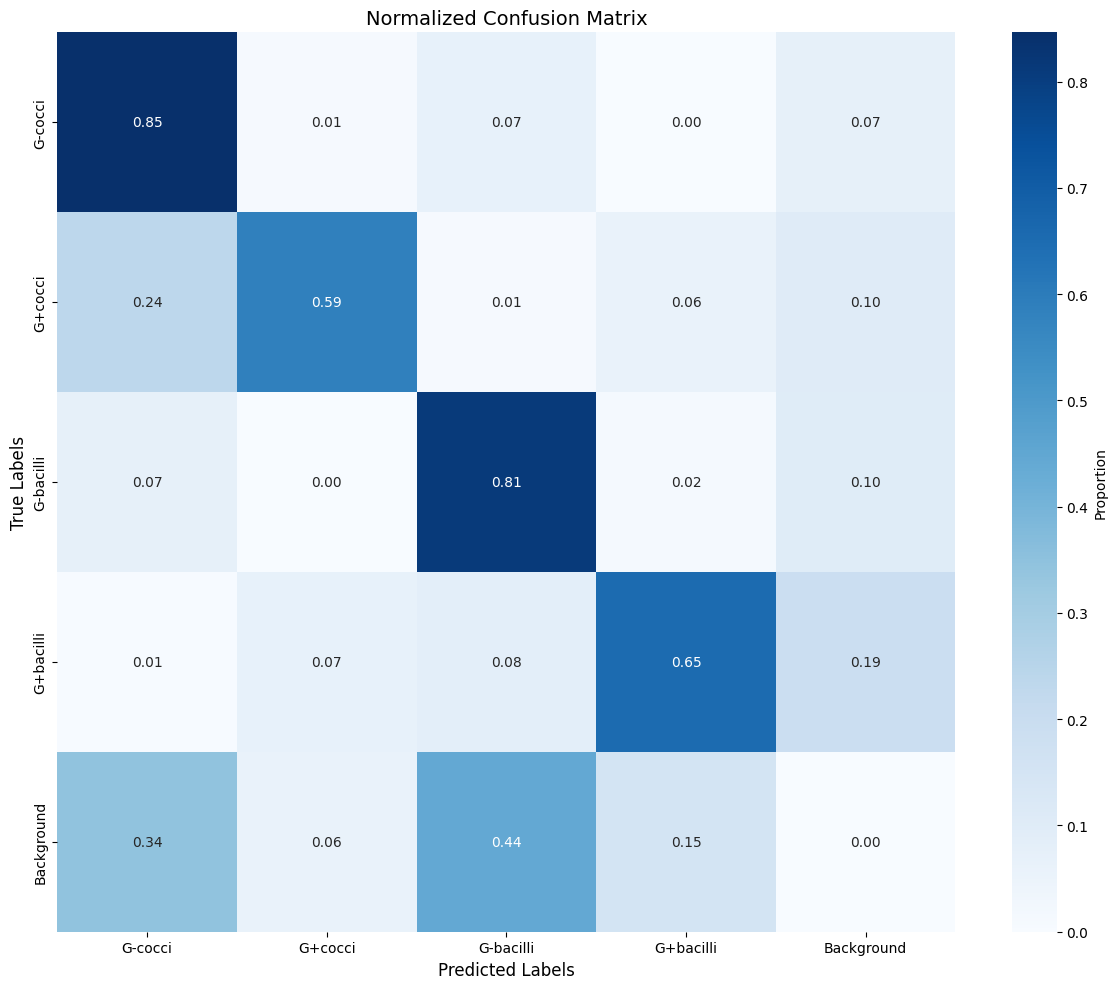

Generating unnormalized confusion matrix...


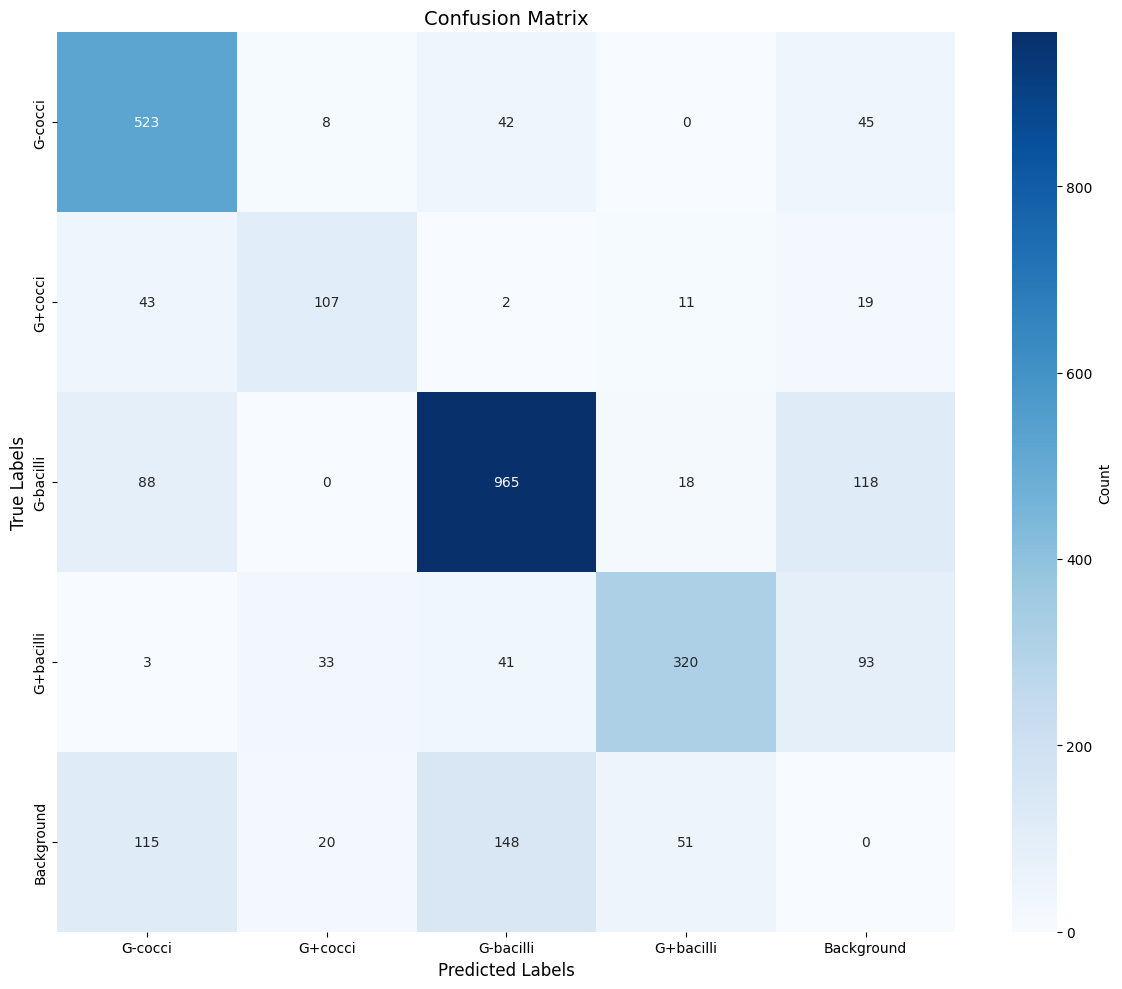

CLASSIFICATION REPORT (Matched Detections Only)
              precision    recall  f1-score   support

     G-cocci       0.80      0.91      0.85       573
     G+cocci       0.72      0.66      0.69       163
   G-bacilli       0.92      0.90      0.91      1071
   G+bacilli       0.92      0.81      0.86       397

    accuracy                           0.87      2204
   macro avg       0.84      0.82      0.83      2204
weighted avg       0.87      0.87      0.87      2204


CLASSIFICATION REPORT (Including FP and FN)
              precision    recall  f1-score   support

     G-cocci       0.68      0.85      0.75       618
     G+cocci       0.64      0.59      0.61       182
   G-bacilli       0.81      0.81      0.81      1189
   G+bacilli       0.80      0.65      0.72       490
  Background       0.00      0.00      0.00       334

    accuracy                           0.68      2813
   macro avg       0.58      0.58      0.58      2813
weighted avg       0.67      0.68     

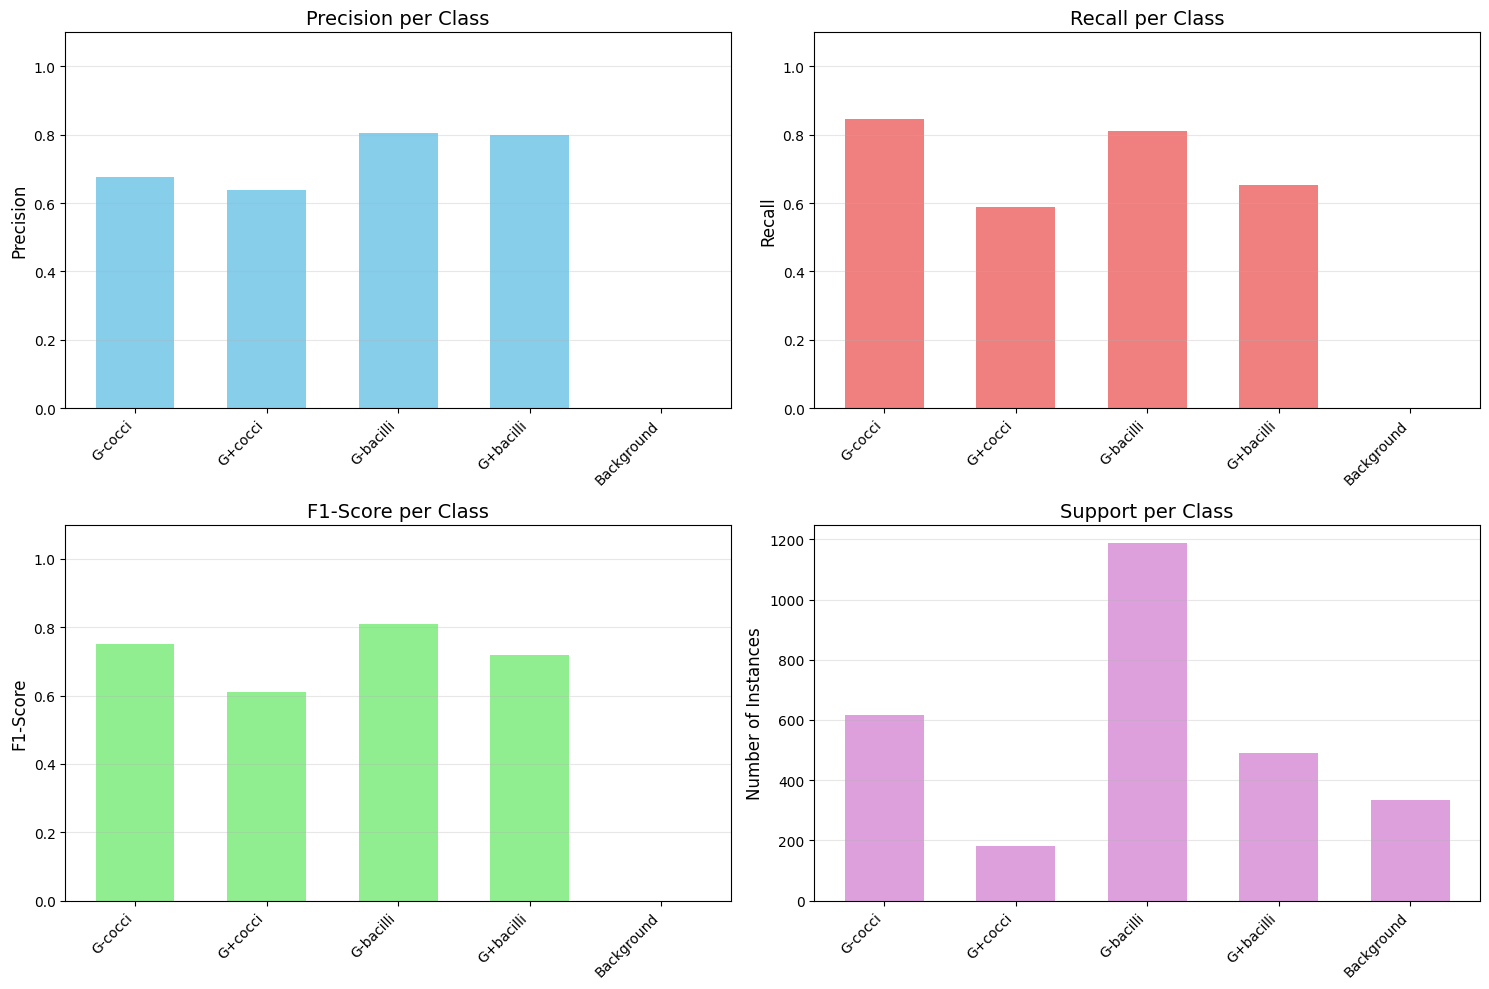


EVALUATION COMPLETE!

Confusion Matrix (raw counts):
[[523   8  42   0  45]
 [ 43 107   2  11  19]
 [ 88   0 965  18 118]
 [  3  33  41 320  93]
 [115  20 148  51   0]]


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tqdm import tqdm
from collections import defaultdict

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def mask_iou(mask1, mask2):
    """Compute IoU between two binary masks"""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0


def box_iou(box1, box2):
    """Compute IoU between two boxes [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0.0


def extract_boxes_from_masks(masks):
    """Extract bounding boxes from binary masks"""
    boxes = []
    for mask in masks:
        if mask.sum() == 0:
            boxes.append([0, 0, 0, 0])
            continue
        
        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        
        if not rows.any() or not cols.any():
            boxes.append([0, 0, 0, 0])
            continue
            
        y_min, y_max = np.where(rows)[0][[0, -1]]
        x_min, x_max = np.where(cols)[0][[0, -1]]
        boxes.append([x_min, y_min, x_max, y_max])
    
    return np.array(boxes, dtype=np.float32)


def compute_ap(scores, matched, fn):
    """Compute Average Precision given scores and match status"""
    if len(scores) == 0:
        return 0.0
    
    # Sort by score
    sorted_idx = np.argsort(-np.array(scores))
    matched = np.array(matched)[sorted_idx]
    
    # Compute precision-recall curve
    tp = np.cumsum(matched)
    fp = np.cumsum(1 - matched)
    
    recalls = tp / (tp[-1] + fn) if (tp[-1] + fn) > 0 else tp * 0
    precisions = tp / (tp + fp)
    
    # Compute AP using 11-point interpolation
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11
    
    return ap


# ============================================================
# INFERENCE AND PREDICTION COLLECTION
# ============================================================

def run_inference_mask2former(model, processor, val_loader, device, threshold=0.5, image_size=256):
    """Run inference and collect predictions"""
    model.eval()
    all_preds = []
    all_targets = []
    
    print("Running inference on validation set...")
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Inference"):
            try:
                pixel_values = batch["pixel_values"].to(device)
                pixel_mask = batch["pixel_mask"].to(device)
                
                class_labels = batch["class_labels"]
                mask_labels = batch["mask_labels"]
                
                # Run inference
                outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)
                
                # Post-process predictions
                target_sizes = [(image_size, image_size)] * len(pixel_values)
                results = processor.post_process_instance_segmentation(
                    outputs, threshold=threshold, target_sizes=target_sizes
                )
                
                # Process each image in batch
                for i in range(len(results)):
                    # Predictions
                    pred_masks_raw = results[i]["segmentation"].cpu().numpy()
                    pred_segments = results[i]["segments_info"]
                    
                    pred_masks = []
                    pred_labels_list = []
                    pred_scores_list = []
                    
                    for seg in pred_segments:
                        seg_id = seg["id"]
                        label_id = seg["label_id"]
                        score = seg.get("score", 1.0)
                        
                        mask = (pred_masks_raw == seg_id).astype(np.uint8)
                        pred_masks.append(mask)
                        pred_labels_list.append(label_id)
                        pred_scores_list.append(score)
                    
                    # Extract boxes from masks
                    if len(pred_masks) > 0:
                        pred_boxes = extract_boxes_from_masks(pred_masks)
                    else:
                        pred_boxes = np.array([]).reshape(0, 4)
                    
                    pred_dict = {
                        "boxes": pred_boxes,
                        "labels": np.array(pred_labels_list),
                        "scores": np.array(pred_scores_list),
                        "masks": np.array(pred_masks)
                    }
                    
                    # Targets
                    tgt_masks = mask_labels[i].cpu().numpy()
                    tgt_labels = class_labels[i].cpu().numpy()
                    
                    if len(tgt_masks) > 0:
                        tgt_boxes = extract_boxes_from_masks(tgt_masks)
                    else:
                        tgt_boxes = np.array([]).reshape(0, 4)
                    
                    tgt_dict = {
                        "boxes": tgt_boxes,
                        "labels": tgt_labels,
                        "masks": tgt_masks
                    }
                    
                    all_preds.append(pred_dict)
                    all_targets.append(tgt_dict)
                    
            except Exception as e:
                print(f"\nError during inference: {e}")
                continue
    
    return all_preds, all_targets


# ============================================================
# DETECTION METRICS
# ============================================================

def compute_detection_metrics(preds, targets, num_classes, iou_thresh=0.5, use_mask_iou=True):
    """
    Compute object detection metrics: Precision, Recall, F1, mAP
    num_classes: 4 (0-3, no background)
    """
    class_stats = {cls: {"tp": 0, "fp": 0, "fn": 0, "scores": [], "matched": []} 
                   for cls in range(num_classes)}
    
    for pred, tgt in zip(preds, targets):
        pred_labels = pred["labels"]
        pred_scores = pred["scores"]
        tgt_labels = tgt["labels"]
        
        if use_mask_iou:
            pred_items = pred["masks"]
            tgt_items = tgt["masks"]
        else:
            pred_items = pred["boxes"]
            tgt_items = tgt["boxes"]
        
        for cls in range(num_classes):
            # Filter predictions and targets for this class
            pred_idx = pred_labels == cls
            tgt_idx = tgt_labels == cls
            
            cls_pred_items = pred_items[pred_idx] if len(pred_items) > 0 else []
            cls_pred_scores = pred_scores[pred_idx] if len(pred_scores) > 0 else []
            cls_tgt_items = tgt_items[tgt_idx] if len(tgt_items) > 0 else []
            
            matched_gt = set()
            
            # Sort predictions by score (highest first)
            if len(cls_pred_scores) > 0:
                sorted_idx = np.argsort(-cls_pred_scores)
                cls_pred_items = cls_pred_items[sorted_idx]
                cls_pred_scores = cls_pred_scores[sorted_idx]
            
            # Match predictions to ground truth
            for pred_item, ps in zip(cls_pred_items, cls_pred_scores):
                best_iou = 0.0
                best_idx = -1
                
                for i, tgt_item in enumerate(cls_tgt_items):
                    if i in matched_gt:
                        continue
                    
                    if use_mask_iou:
                        iou = mask_iou(pred_item, tgt_item)
                    else:
                        iou = box_iou(pred_item, tgt_item)
                    
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = i
                
                if best_iou >= iou_thresh and best_idx != -1:
                    class_stats[cls]["tp"] += 1
                    class_stats[cls]["matched"].append(1)
                    matched_gt.add(best_idx)
                else:
                    class_stats[cls]["fp"] += 1
                    class_stats[cls]["matched"].append(0)
                
                class_stats[cls]["scores"].append(ps)
            
            # Count false negatives
            class_stats[cls]["fn"] += len(cls_tgt_items) - len(matched_gt)
    
    # Compute metrics per class
    results = {}
    all_precisions = []
    all_recalls = []
    all_f1s = []
    all_aps = []
    
    for cls in range(num_classes):
        tp = class_stats[cls]["tp"]
        fp = class_stats[cls]["fp"]
        fn = class_stats[cls]["fn"]
        scores = class_stats[cls]["scores"]
        matched = class_stats[cls]["matched"]
        
        # Precision, Recall, F1
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        # Average Precision (AP)
        ap = compute_ap(scores, matched, fn)
        
        results[f"det_precision_class_{cls}"] = precision
        results[f"det_recall_class_{cls}"] = recall
        results[f"det_f1_class_{cls}"] = f1
        results[f"det_ap_class_{cls}"] = ap
        
        all_precisions.append(precision)
        all_recalls.append(recall)
        all_f1s.append(f1)
        all_aps.append(ap)
    
    # Mean metrics
    results["det_mean_precision"] = np.mean(all_precisions)
    results["det_mean_recall"] = np.mean(all_recalls)
    results["det_mean_f1"] = np.mean(all_f1s)
    results["det_mAP"] = np.mean(all_aps)
    
    return results


# ============================================================
# CLASSIFICATION METRICS
# ============================================================

def compute_classification_metrics(preds, targets, num_classes, iou_thresh=0.5, use_mask_iou=True):
    """
    Compute classification metrics: Accuracy, Precision, Recall, F1
    Treats each detected object as a classification instance
    """
    class_stats = {cls: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} 
                   for cls in range(num_classes)}
    
    for pred, tgt in zip(preds, targets):
        pred_labels = pred["labels"]
        tgt_labels = tgt["labels"]
        
        if use_mask_iou:
            pred_items = pred["masks"]
            tgt_items = tgt["masks"]
        else:
            pred_items = pred["boxes"]
            tgt_items = tgt["boxes"]
        
        # Match predictions to ground truth based on IoU
        matched_gt = set()
        matched_pred = set()
        
        for i in range(len(pred_items)):
            best_iou = 0.0
            best_idx = -1
            
            for j in range(len(tgt_items)):
                if j in matched_gt:
                    continue
                
                if use_mask_iou:
                    iou = mask_iou(pred_items[i], tgt_items[j])
                else:
                    iou = box_iou(pred_items[i], tgt_items[j])
                
                if iou > best_iou:
                    best_iou = iou
                    best_idx = j
            
            if best_iou >= iou_thresh and best_idx != -1:
                matched_gt.add(best_idx)
                matched_pred.add(i)
                
                pred_cls = pred_labels[i]
                true_cls = tgt_labels[best_idx]
                
                # Update stats for all classes
                for cls in range(num_classes):
                    if pred_cls == cls and true_cls == cls:
                        class_stats[cls]["tp"] += 1
                    elif pred_cls == cls and true_cls != cls:
                        class_stats[cls]["fp"] += 1
                    elif pred_cls != cls and true_cls == cls:
                        class_stats[cls]["fn"] += 1
                    else:
                        class_stats[cls]["tn"] += 1
        
        # Unmatched predictions are false positives
        for i in range(len(pred_labels)):
            if i not in matched_pred:
                pred_cls = pred_labels[i]
                class_stats[pred_cls]["fp"] += 1
        
        # Unmatched ground truths are false negatives
        for j in range(len(tgt_labels)):
            if j not in matched_gt:
                true_cls = tgt_labels[j]
                class_stats[true_cls]["fn"] += 1
    
    # Compute metrics per class
    results = {}
    all_accuracies = []
    all_precisions = []
    all_recalls = []
    all_f1s = []
    
    for cls in range(num_classes):
        tp = class_stats[cls]["tp"]
        fp = class_stats[cls]["fp"]
        fn = class_stats[cls]["fn"]
        tn = class_stats[cls]["tn"]
        
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[f"clf_accuracy_class_{cls}"] = accuracy
        results[f"clf_precision_class_{cls}"] = precision
        results[f"clf_recall_class_{cls}"] = recall
        results[f"clf_f1_class_{cls}"] = f1
        
        all_accuracies.append(accuracy)
        all_precisions.append(precision)
        all_recalls.append(recall)
        all_f1s.append(f1)
    
    # Mean metrics
    results["clf_mean_accuracy"] = np.mean(all_accuracies)
    results["clf_mean_precision"] = np.mean(all_precisions)
    results["clf_mean_recall"] = np.mean(all_recalls)
    results["clf_mean_f1"] = np.mean(all_f1s)
    
    return results


# ============================================================
# SEGMENTATION METRICS
# ============================================================

def compute_instance_metrics_classwise(preds, targets, num_classes, iou_thresh=0.5, smooth=1e-6):
    """Compute instance segmentation metrics per class"""
    class_stats = {cls: {"tp": 0, "fp": 0, "fn": 0, "ious": []} for cls in range(num_classes)}

    for pred, tgt in zip(preds, targets):
        pred_masks = pred["masks"] if len(pred["masks"]) > 0 else []
        pred_labels = pred["labels"] if len(pred["labels"]) > 0 else []
        tgt_masks = tgt["masks"] if len(tgt["masks"]) > 0 else []
        tgt_labels = tgt["labels"] if len(tgt["labels"]) > 0 else []

        for cls in range(num_classes):
            pmasks = [m for m, l in zip(pred_masks, pred_labels) if l == cls]
            tmasks = [m for m, l in zip(tgt_masks, tgt_labels) if l == cls]
            matched_gt = set()

            for pm in pmasks:
                best_iou = 0.0
                best_idx = -1
                for i, tm in enumerate(tmasks):
                    inter = np.logical_and(pm, tm).sum()
                    union = np.logical_or(pm, tm).sum()
                    iou = (inter + smooth) / (union + smooth)
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = i
                if best_iou >= iou_thresh:
                    class_stats[cls]["tp"] += 1
                    class_stats[cls]["ious"].append(best_iou)
                    matched_gt.add(best_idx)
                else:
                    class_stats[cls]["fp"] += 1

            class_stats[cls]["fn"] += len(tmasks) - len(matched_gt)

    # Compute metrics per class
    results = {}
    for cls in range(num_classes):
        tp = class_stats[cls]["tp"]
        fp = class_stats[cls]["fp"]
        fn = class_stats[cls]["fn"]
        ious = class_stats[cls]["ious"]

        precision = tp / (tp + fp + smooth)
        recall = tp / (tp + fn + smooth)
        mean_iou = np.mean(ious) if ious else 0.0
        dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        acc = tp / (tp + fp + fn + smooth)

        results[f"precision_class_{cls}"] = precision
        results[f"recall_class_{cls}"] = recall
        results[f"iou_class_{cls}"] = mean_iou
        results[f"dice_class_{cls}"] = dice
        results[f"accuracy_class_{cls}"] = acc

    # Mean metrics
    results["mean_precision"] = np.mean([results[f"precision_class_{c}"] for c in range(num_classes)])
    results["mean_recall"] = np.mean([results[f"recall_class_{c}"] for c in range(num_classes)])
    results["mean_iou"] = np.mean([results[f"iou_class_{c}"] for c in range(num_classes)])
    results["mean_dice"] = np.mean([results[f"dice_class_{c}"] for c in range(num_classes)])
    results["mean_accuracy"] = np.mean([results[f"accuracy_class_{c}"] for c in range(num_classes)])

    return results


# ============================================================
# CONFUSION MATRIX AND VISUALIZATION
# ============================================================

def collect_matched_predictions(preds, targets, iou_thresh=0.5, score_thresh=0.5, use_mask_iou=True):
    """Match predictions to ground truth for confusion matrix"""
    all_pred_labels = []
    all_true_labels = []
    
    for pred, tgt in zip(preds, targets):
        pred_labels = pred["labels"]
        pred_scores = pred["scores"]
        tgt_labels = tgt["labels"]
        
        # Filter by score threshold
        if len(pred_scores) > 0:
            score_mask = pred_scores >= score_thresh
            pred_labels = pred_labels[score_mask]
            
            if use_mask_iou:
                pred_items = pred["masks"][score_mask]
            else:
                pred_items = pred["boxes"][score_mask]
        else:
            pred_labels = np.array([])
            pred_items = np.array([])
        
        if use_mask_iou:
            tgt_items = tgt["masks"]
        else:
            tgt_items = tgt["boxes"]
        
        matched_gt = set()
        
        for i in range(len(pred_items)):
            best_iou = 0.0
            best_idx = -1
            
            for j in range(len(tgt_items)):
                if j in matched_gt:
                    continue
                
                if use_mask_iou:
                    iou = mask_iou(pred_items[i], tgt_items[j])
                else:
                    iou = box_iou(pred_items[i], tgt_items[j])
                
                if iou > best_iou:
                    best_iou = iou
                    best_idx = j
            
            if best_iou >= iou_thresh and best_idx != -1:
                matched_gt.add(best_idx)
                all_pred_labels.append(pred_labels[i])
                all_true_labels.append(tgt_labels[best_idx])
            else:
                # False positive
                all_pred_labels.append(pred_labels[i])
                all_true_labels.append(4)  # Background
        
        # False negatives
        for j in range(len(tgt_labels)):
            if j not in matched_gt:
                all_pred_labels.append(4)  # Predicted as background
                all_true_labels.append(tgt_labels[j])
    
    return np.array(all_pred_labels), np.array(all_true_labels)


def plot_confusion_matrix(all_pred_labels, all_true_labels, class_names, 
                          save_path='confusion_matrix.png', normalize=True):
    """Plot confusion matrix"""
    cm = confusion_matrix(all_true_labels, all_pred_labels)
    
    if normalize:
        cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
        fmt = '.2f'
        title = 'Normalized Confusion Matrix'
    else:
        cm_normalized = cm
        fmt = 'd'
        title = 'Confusion Matrix'
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_normalized, annot=True, fmt=fmt, cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, 
                cbar_kws={'label': 'Proportion' if normalize else 'Count'})
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return cm


def print_classification_report(all_pred_labels, all_true_labels, class_names):
    """Print classification reports"""
    # Matched detections only
    non_bg_mask = all_true_labels != 4
    filtered_true = all_true_labels[non_bg_mask]
    filtered_pred = all_pred_labels[non_bg_mask]
    
    non_bg_pred_mask = filtered_pred != 4
    filtered_true = filtered_true[non_bg_pred_mask]
    filtered_pred = filtered_pred[non_bg_pred_mask]
    
    print("="*80)
    print("CLASSIFICATION REPORT (Matched Detections Only)")
    print("="*80)
    if len(filtered_true) > 0:
        report = classification_report(
            filtered_true, filtered_pred, 
            labels=list(range(4)),
            target_names=class_names[:-1],
            zero_division=0
        )
        print(report)
    else:
        print("No matched detections found!")
    
    print("\n" + "="*80)
    print("CLASSIFICATION REPORT (Including FP and FN)")
    print("="*80)
    report_full = classification_report(
        all_true_labels, all_pred_labels, 
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0
    )
    print(report_full)


def plot_per_class_performance(all_pred_labels, all_true_labels, class_names, 
                               save_path='per_class_performance.png'):
    """Plot per-class performance bars"""
    precision, recall, f1, support = precision_recall_fscore_support(
        all_true_labels, all_pred_labels, 
        labels=list(range(len(class_names))),
        zero_division=0
    )
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    x = np.arange(len(class_names))
    width = 0.6
    
    axes[0, 0].bar(x, precision, width, color='skyblue')
    axes[0, 0].set_ylabel('Precision', fontsize=12)
    axes[0, 0].set_title('Precision per Class', fontsize=14)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0, 0].set_ylim([0, 1.1])
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    axes[0, 1].bar(x, recall, width, color='lightcoral')
    axes[0, 1].set_ylabel('Recall', fontsize=12)
    axes[0, 1].set_title('Recall per Class', fontsize=14)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0, 1].set_ylim([0, 1.1])
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    axes[1, 0].bar(x, f1, width, color='lightgreen')
    axes[1, 0].set_ylabel('F1-Score', fontsize=12)
    axes[1, 0].set_title('F1-Score per Class', fontsize=14)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1, 0].set_ylim([0, 1.1])
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    axes[1, 1].bar(x, support, width, color='plum')
    axes[1, 1].set_ylabel('Number of Instances', fontsize=12)
    axes[1, 1].set_title('Support per Class', fontsize=14)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# PRINT ALL METRICS
# ============================================================

def print_all_metrics(metrics, num_classes, class_labels):
    """Print all metrics in organized format"""
    print("="*80)
    print("OBJECT DETECTION METRICS")
    print("="*80)
    for cls in range(num_classes):
        print(f"\n{class_labels[cls]}:")
        print(f"  Precision: {metrics[f'det_precision_class_{cls}']:.4f}")
        print(f"  Recall:    {metrics[f'det_recall_class_{cls}']:.4f}")
        print(f"  F1 Score:  {metrics[f'det_f1_class_{cls}']:.4f}")
        print(f"  AP:        {metrics[f'det_ap_class_{cls}']:.4f}")
    
    print(f"\nOverall Detection:")
    print(f"  Mean Precision: {metrics['det_mean_precision']:.4f}")
    print(f"  Mean Recall:    {metrics['det_mean_recall']:.4f}")
    print(f"  Mean F1:        {metrics['det_mean_f1']:.4f}")
    print(f"  mAP:            {metrics['det_mAP']:.4f}")
    
    print("\n" + "="*80)
    print("CLASSIFICATION METRICS")
    print("="*80)
    for cls in range(num_classes):
        print(f"\n{class_labels[cls]}:")
        print(f"  Accuracy:  {metrics[f'clf_accuracy_class_{cls}']:.4f}")
        print(f"  Precision: {metrics[f'clf_precision_class_{cls}']:.4f}")
        print(f"  Recall:    {metrics[f'clf_recall_class_{cls}']:.4f}")
        print(f"  F1 Score:  {metrics[f'clf_f1_class_{cls}']:.4f}")
    
    print(f"\nOverall Classification:")
    print(f"  Mean Accuracy:  {metrics['clf_mean_accuracy']:.4f}")
    print(f"  Mean Precision: {metrics['clf_mean_precision']:.4f}")
    print(f"  Mean Recall:    {metrics['clf_mean_recall']:.4f}")
    print(f"  Mean F1:        {metrics['clf_mean_f1']:.4f}")
    
    print("\n" + "="*80)
    print("SEGMENTATION METRICS")
    print("="*80)
    for cls in range(num_classes):
        print(f"\n{class_labels[cls]}:")
        print(f"  Dice:      {metrics[f'dice_class_{cls}']:.4f}")
        print(f"  IoU:       {metrics[f'iou_class_{cls}']:.4f}")
        print(f"  Precision: {metrics[f'precision_class_{cls}']:.4f}")
        print(f"  Recall:    {metrics[f'recall_class_{cls}']:.4f}")
        print(f"  Accuracy:  {metrics[f'accuracy_class_{cls}']:.4f}")
    
    print(f"\nOverall Segmentation:")
    print(f"  Mean Dice:      {metrics['mean_dice']:.4f}")
    print(f"  Mean IoU:       {metrics['mean_iou']:.4f}")
    print(f"  Mean Precision: {metrics['mean_precision']:.4f}")
    print(f"  Mean Recall:    {metrics['mean_recall']:.4f}")
    print(f"  Mean Accuracy:  {metrics['mean_accuracy']:.4f}")


# ============================================================
# MAIN EVALUATION FUNCTION
# ============================================================

def evaluate_mask2former_comprehensive(model, processor, val_loader, device, 
                                      class_labels, num_classes=4, 
                                      iou_thresh=0.5, score_thresh=0.5, 
                                      use_mask_iou=True, image_size=256):
    """
    Complete comprehensive evaluation combining all metrics
    
    Args:
        model: Mask2Former model
        processor: Mask2Former processor
        val_loader: validation DataLoader
        device: torch device
        class_labels: list of class names (4 classes)
        num_classes: number of classes (default 4)
        iou_thresh: IoU threshold
        score_thresh: confidence threshold
        use_mask_iou: use mask IoU vs box IoU
        image_size: image size for post-processing
    """
    # Device setup
    if torch.cuda.is_available():
        print(f"CUDA is available. Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("CUDA is not available. Using CPU.")
    
    # Run inference
    all_preds, all_targets = run_inference_mask2former(
        model, processor, val_loader, device, 
        threshold=score_thresh, image_size=image_size
    )
    
    print(f"\nCollected {len(all_preds)} predictions and {len(all_targets)} targets")
    
    # Compute all metrics
    print("\nComputing Detection Metrics...")
    det_metrics = compute_detection_metrics(all_preds, all_targets, num_classes, 
                                           iou_thresh, use_mask_iou)
    
    print("Computing Classification Metrics...")
    clf_metrics = compute_classification_metrics(all_preds, all_targets, num_classes, 
                                                 iou_thresh, use_mask_iou)
    
    print("Computing Segmentation Metrics...")
    seg_metrics = compute_instance_metrics_classwise(all_preds, all_targets, num_classes, 
                                                     iou_thresh)
    
    # Combine all metrics
    all_metrics = {**det_metrics, **clf_metrics, **seg_metrics}
    
    # Print comprehensive results
    print("\n" + "="*80)
    print("COMPREHENSIVE EVALUATION RESULTS")
    print("="*80)
    print_all_metrics(all_metrics, num_classes, class_labels)
    
    # Confusion matrix and visualization
    print("\n" + "="*80)
    print("GENERATING CONFUSION MATRIX AND VISUALIZATIONS")
    print("="*80)
    
    class_names_with_bg = class_labels + ['Background']
    
    print("\nMatching predictions to ground truth...")
    all_pred_labels, all_true_labels = collect_matched_predictions(
        all_preds, all_targets, iou_thresh, score_thresh, use_mask_iou
    )
    
    print(f"\nTotal instances collected: {len(all_pred_labels)}")
    print(f"  - True Positives/Misclassifications: {np.sum((all_pred_labels < 4) & (all_true_labels < 4))}")
    print(f"  - False Positives: {np.sum((all_pred_labels < 4) & (all_true_labels == 4))}")
    print(f"  - False Negatives: {np.sum((all_pred_labels == 4) & (all_true_labels < 4))}")
    
    # Plot confusion matrices
    print("\nGenerating normalized confusion matrix...")
    cm_norm = plot_confusion_matrix(all_pred_labels, all_true_labels, class_names_with_bg,
                                    save_path='mask2former_confusion_matrix_normalized.png',
                                    normalize=True)
    
    print("Generating unnormalized confusion matrix...")
    cm_raw = plot_confusion_matrix(all_pred_labels, all_true_labels, class_names_with_bg,
                                   save_path='mask2former_confusion_matrix_raw.png',
                                   normalize=False)
    
    # Print classification report
    print_classification_report(all_pred_labels, all_true_labels, class_names_with_bg)
    
    # Plot per-class performance
    print("\nGenerating per-class performance plots...")
    plot_per_class_performance(all_pred_labels, all_true_labels, class_names_with_bg,
                              save_path='mask2former_per_class_performance.png')
    
    print("\n" + "="*80)
    print("EVALUATION COMPLETE!")
    print("="*80)
    
    return all_metrics, all_preds, all_targets, all_pred_labels, all_true_labels, cm_raw


# ============================================================
# USAGE EXAMPLE
# ============================================================

if __name__ == "__main__":
    # Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor
    
    # Load model
    model_name = "facebook/mask2former-swin-tiny-coco-instance"
    processor = Mask2FormerImageProcessor.from_pretrained(
        model_name,
        do_reduce_labels=False,
        ignore_index=255,
        size={"height": 256, "width": 256}
    )
    
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        model_name,
        num_labels=4,
        ignore_mismatched_sizes=True
    )
    
    # Load trained weights
    checkpoint = torch.load("best_mask2former_bacteria.pth", weights_only=False, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"Loaded model from epoch {checkpoint.get('epoch', 'N/A')}")
    print(f"Best Dice score: {checkpoint.get('dice', 'N/A'):.4f}")
    
    # Class labels
    class_labels = ['G-cocci', 'G+cocci', 'G-bacilli', 'G+bacilli']
    
    # Run comprehensive evaluation
    all_metrics, all_preds, all_targets, all_pred_labels, all_true_labels, cm = \
        evaluate_mask2former_comprehensive(
            model=model,
            processor=processor,
            val_loader=val_loader,  # Assuming val_loader is defined
            device=device,
            class_labels=class_labels,
            num_classes=4,
            iou_thresh=0.5,
            score_thresh=0.5,
            use_mask_iou=True,  # Use mask IoU (recommended)
            image_size=256
        )
    
    print("\nConfusion Matrix (raw counts):")
    print(cm)